# **🏅 Case Study: Olympic Medal Data Analysis**


In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#PART 1 — Data Understanding
Q1. Load the dataset.
Display first 5 rows.


Print number of rows and columns.


Display column names.



Q2. Check data types.
Which columns are numerical?


Which are categorical?



Q3. Missing Values
Find number of missing values in each column.


Why does the Medal column have many missing values?




In [44]:
data=pd.read_csv('/content/athlete_events - medal.csv')
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [45]:
data.shape

(246864, 15)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246864 entries, 0 to 246863
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      246864 non-null  int64  
 1   Name    246864 non-null  object 
 2   Sex     246864 non-null  object 
 3   Age     238197 non-null  float64
 4   Height  192051 non-null  float64
 5   Weight  189517 non-null  float64
 6   Team    246864 non-null  object 
 7   NOC     246864 non-null  object 
 8   Games   246864 non-null  object 
 9   Year    246863 non-null  float64
 10  Season  246863 non-null  object 
 11  City    246863 non-null  object 
 12  Sport   246863 non-null  object 
 13  Event   246863 non-null  object 
 14  Medal   35956 non-null   object 
dtypes: float64(4), int64(1), object(10)
memory usage: 28.3+ MB


In [47]:
data.dtypes

,0
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,float64


In [48]:
missing_values = data.isnull().sum()
print("Number of missing values per column:")
print(missing_values)

Number of missing values per column:
ID             0
Name           0
Sex            0
Age         8667
Height     54813
Weight     57347
Team           0
NOC            0
Games          0
Year           1
Season         1
City           1
Sport          1
Event          1
Medal     210908
dtype: int64


In [49]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")


Numerical Columns: ['ID', 'Age', 'Height', 'Weight', 'Year']
Categorical Columns: ['Name', 'Sex', 'Team', 'NOC', 'Games', 'Season', 'City', 'Sport', 'Event', 'Medal']


# PART 2 — Medal Filtering


**Q4**. Create a new DataFrame containing only medal winners.
Remove rows where Medal is null.


Display first 5 rows of medal winners dataset.




In [50]:
medal_winners = data[data['Medal'].notnull()]
print(medal_winners.head())

    ID                      Name Sex   Age  Height  Weight            Team  \
3    4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
37  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         Finland   
38  15      Arvo Ossian Aaltonen   M  30.0     NaN     NaN         Finland   
40  16  Juhamatti Tapio Aaltonen   M  28.0   184.0    85.0         Finland   
41  17   Paavo Johannes Aaltonen   M  28.0   175.0    64.0         Finland   

    NOC        Games    Year  Season       City       Sport  \
3   DEN  1900 Summer  1900.0  Summer      Paris  Tug-Of-War   
37  FIN  1920 Summer  1920.0  Summer  Antwerpen    Swimming   
38  FIN  1920 Summer  1920.0  Summer  Antwerpen    Swimming   
40  FIN  2014 Winter  2014.0  Winter      Sochi  Ice Hockey   
41  FIN  1948 Summer  1948.0  Summer     London  Gymnastics   

                                     Event   Medal  
3              Tug-Of-War Men's Tug-Of-War    Gold  
37  Swimming Men's 200 metres Breaststroke  Br

# PART 3 — Country Analysis
Q5. Total Medal Count
Find total medals won by each country.


Display top 10 countries.



Q6. Visualize Top 10 Countries
Create a bar chart of top 10 countries by total medals.



Q7. Gold Medal Analysis
Filter only Gold medals.


Find top 10 countries with most Gold medals.


Plot a bar chart.




In [51]:

country_medals = medal_winners.groupby('Team')['Medal'].count().sort_values(ascending=False)

top10_countries = country_medals.head(10)

print(top10_countries)

Team
United States    4793
Soviet Union     2226
Germany          1723
Great Britain    1545
France           1497
Italy            1425
Sweden           1342
Australia        1205
Canada           1140
Hungary          1040
Name: Medal, dtype: int64


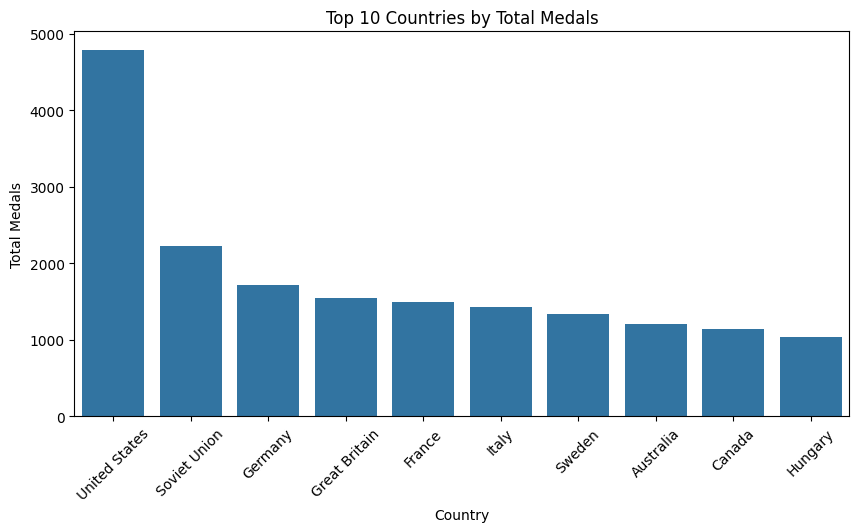

In [52]:

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10_countries.index,
    y=top10_countries.values
)

plt.xticks(rotation=45)
plt.title("Top 10 Countries by Total Medals")
plt.xlabel("Country")
plt.ylabel("Total Medals")

plt.show()

In [53]:

gold_medals = medal_winners[medal_winners['Medal'] == 'Gold']

top10_gold = gold_medals.groupby('Team')['Medal'].count().sort_values(ascending=False).head(10)

print(top10_gold)

Team
United States    2264
Soviet Union      965
Germany           586
Italy             494
Great Britain     477
France            442
Sweden            416
Hungary           402
Canada            391
East Germany      329
Name: Medal, dtype: int64


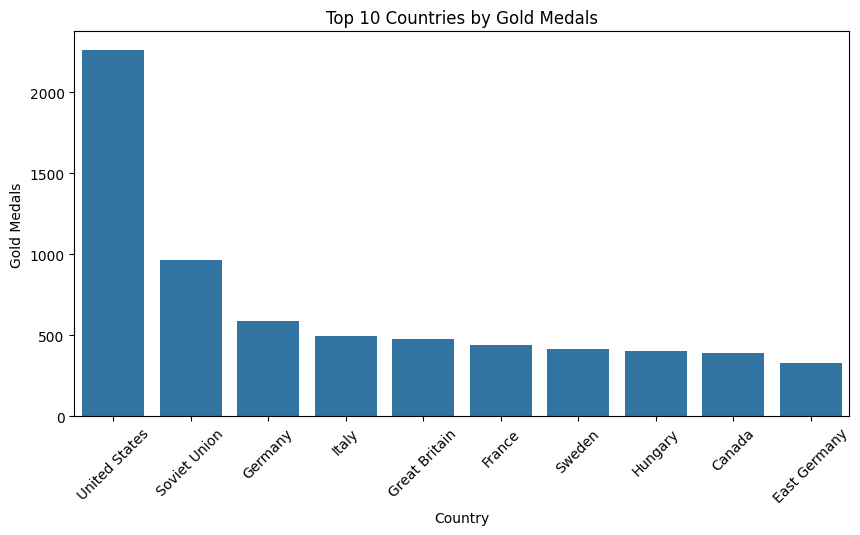

In [54]:

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10_gold.index,
    y=top10_gold.values
)

plt.xticks(rotation=45)
plt.title("Top 10 Countries by Gold Medals")
plt.xlabel("Country")
plt.ylabel("Gold Medals")

plt.show()

# PART 4 — Gender Analysis
Q8. Gender Distribution
Find total medals won by Male and Female athletes.


Visualize using countplot or bar chart.



Q9. Gender Trend Over Years
Group data by Year and Sex.


Plot medal trend over years for Male and Female athletes.





In [55]:

gender_medals = medal_winners.groupby('Sex')['Medal'].count()

print(gender_medals)

Sex
F     9984
M    25972
Name: Medal, dtype: int64


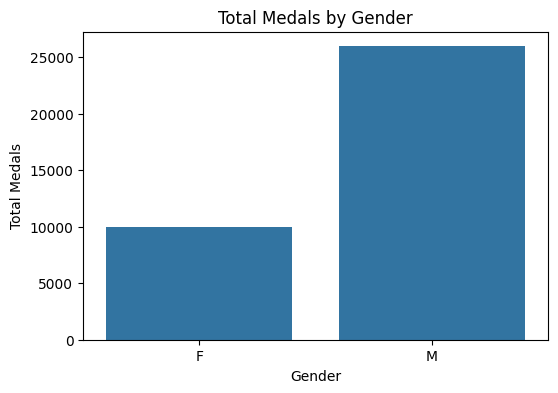

In [56]:

plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_medals.index,
    y=gender_medals.values
)

plt.title("Total Medals by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Medals")

plt.show()

In [57]:

gender_trend = medal_winners.groupby(['Year', 'Sex'])['Medal'].count().reset_index()

print(gender_trend.head())

     Year Sex  Medal
0  1896.0   M    129
1  1900.0   F     12
2  1900.0   M    543
3  1904.0   F      9
4  1904.0   M    422


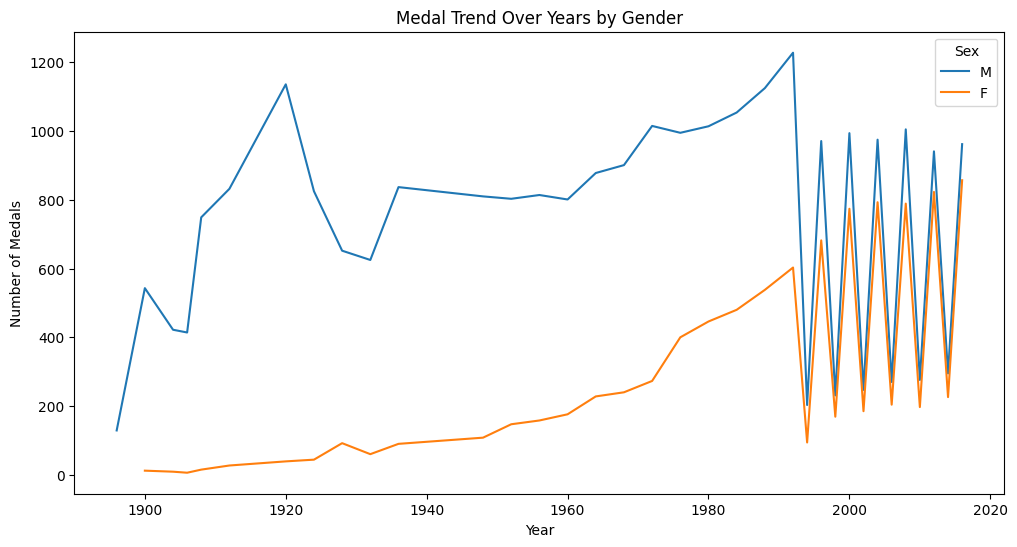

In [58]:

plt.figure(figsize=(12,6))

sns.lineplot(
    data=gender_trend,
    x='Year',
    y='Medal',
    hue='Sex'
)

plt.title("Medal Trend Over Years by Gender")
plt.xlabel("Year")
plt.ylabel("Number of Medals")

plt.show()

# PART 5 — Sport Analysis
Q10. Top Sports
Find top 10 sports by total medals.


Plot a bar chart.



Q11. Gold Medal Sport
Which sport gives the highest number of Gold medals?


In [59]:

top_sports = medal_winners.groupby('Sport')['Medal'].count().sort_values(ascending=False).head(10)

print(top_sports)

Sport
Athletics     3654
Swimming      2717
Rowing        2683
Gymnastics    2049
Fencing       1599
Football      1439
Ice Hockey    1414
Hockey        1366
Wrestling     1178
Cycling       1131
Name: Medal, dtype: int64


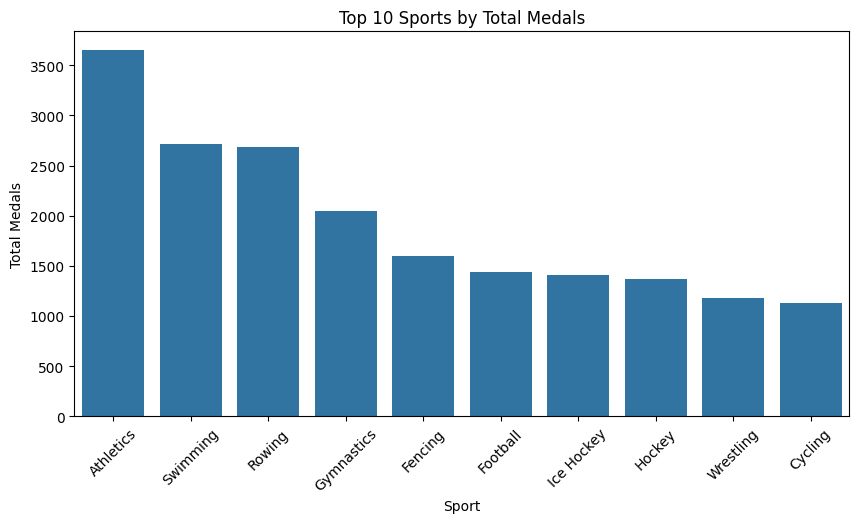

In [60]:

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_sports.index,
    y=top_sports.values
)

plt.xticks(rotation=45)
plt.title("Top 10 Sports by Total Medals")
plt.xlabel("Sport")
plt.ylabel("Total Medals")

plt.show()

In [61]:

gold_sport = gold_medals.groupby('Sport')['Medal'].count().sort_values(ascending=False)

print(gold_sport.head(1))

Sport
Athletics    1230
Name: Medal, dtype: int64


# PART 6 — Year-wise Analysis
Q12. Medal Trend Over Time
Find total medals per year.


Plot a line graph.



Q13. Best Olympic Year
Which year had the highest number of medals awarded?




In [62]:

year_medals = medal_winners.groupby('Year')['Medal'].count()

print(year_medals)

Year
1896.0     129
1900.0     555
1904.0     431
1906.0     420
1908.0     764
1912.0     859
1920.0    1175
1924.0     869
1928.0     744
1932.0     685
1936.0     927
1948.0     918
1952.0     950
1956.0     972
1960.0     977
1964.0    1106
1968.0    1141
1972.0    1288
1976.0    1395
1980.0    1460
1984.0    1534
1988.0    1663
1992.0    1831
1994.0     297
1996.0    1653
1998.0     400
2000.0    1768
2002.0     432
2004.0    1768
2006.0     474
2008.0    1794
2010.0     473
2012.0    1764
2014.0     521
2016.0    1819
Name: Medal, dtype: int64


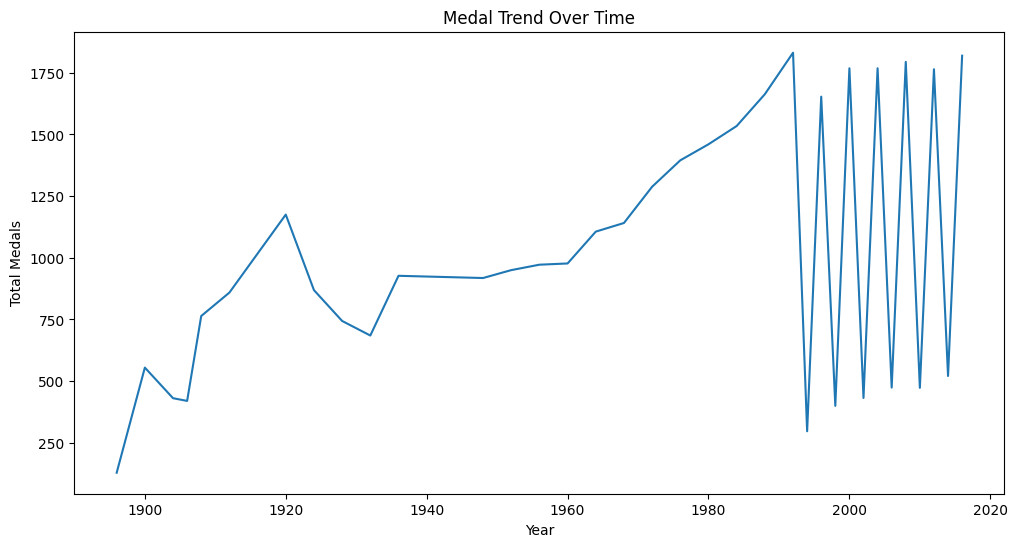

In [63]:

plt.figure(figsize=(12,6))

sns.lineplot(
    x=year_medals.index,
    y=year_medals.values
)

plt.title("Medal Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Medals")

plt.show()

In [64]:
best_year = year_medals.idxmax()
highest_medals = year_medals.max()

print("Best Olympic Year :", best_year)
print("Highest Medals Awarded :", highest_medals)

Best Olympic Year : 1992.0
Highest Medals Awarded : 1831


# PART 7 — Age Analysis
Q14. Age Distribution
Plot histogram of age of medal winners.


What is the most common winning age range?



Q15. Average Age by Medal Type
Find average age for Gold, Silver, and Bronze medal winners.








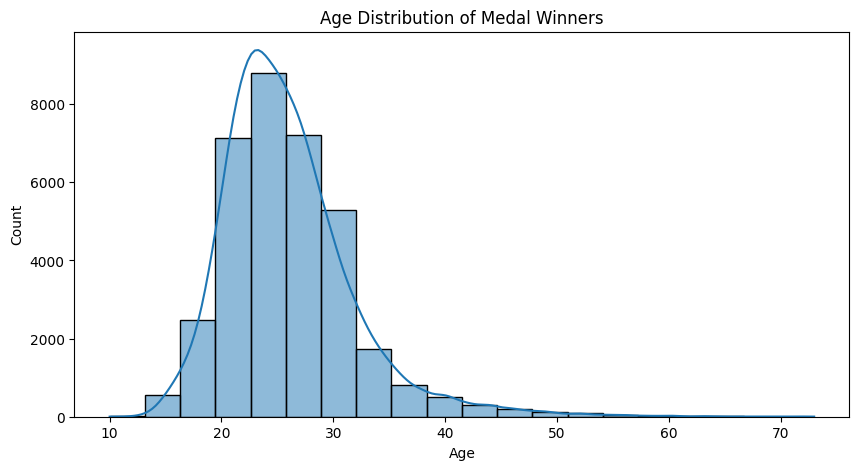

In [65]:

plt.figure(figsize=(10,5))

sns.histplot(
    medal_winners['Age'].dropna(),
    bins=20,
    kde=True
)

plt.title("Age Distribution of Medal Winners")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [66]:

age_range = pd.cut(medal_winners['Age'], bins=[10,15,20,25,30,35,40,45,50])

print(age_range.value_counts().sort_values(ascending=False).head(1))

Age
(20, 25]    14115
Name: count, dtype: int64


In [67]:

avg_age = medal_winners.groupby('Medal')['Age'].mean()

print(avg_age)

Medal
Bronze    25.902074
Gold      25.906690
Silver    26.027022
Name: Age, dtype: float64


# PART 8 — Correlation & Numerical Insight
Q16. Correlation Matrix
Create correlation heatmap for numerical columns (Age, Height, Weight).


Which two variables are most correlated?


In [68]:
corr = data[['Age', 'Height', 'Weight']].corr()

print(corr)

             Age    Height    Weight
Age     1.000000  0.138186  0.211646
Height  0.138186  1.000000  0.795568
Weight  0.211646  0.795568  1.000000


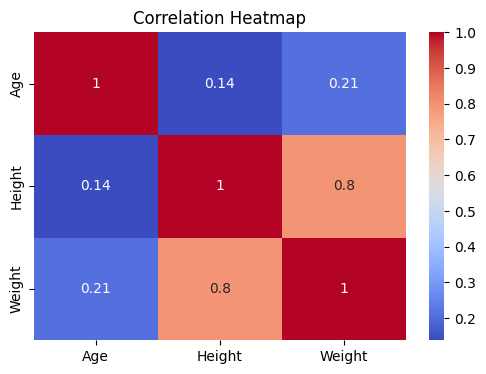

In [69]:

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [70]:

print(corr.unstack().sort_values(ascending=False))

Age     Age       1.000000
Height  Height    1.000000
Weight  Weight    1.000000
Height  Weight    0.795568
Weight  Height    0.795568
Age     Weight    0.211646
Weight  Age       0.211646
Height  Age       0.138186
Age     Height    0.138186
dtype: float64


# PART 9 — Mini Investigation (Open-Ended)
Q17. Country Performance
Choose one country:
Total medals


Gold medals


Best sport


Medal trend over years


Present your findings.

Q18. Sport Deep Dive
Choose one sport:
Which country dominates?


Gender participation trend


Average age of winners


In [71]:

country = 'United States'

country_data = medal_winners[medal_winners['Team'] == country]

total_medals = country_data['Medal'].count()
print("Total Medals :", total_medals)
gold_count = country_data[country_data['Medal'] == 'Gold']['Medal'].count()
print("Gold Medals :", gold_count)

best_sport = country_data.groupby('Sport')['Medal'].count().sort_values(ascending=False).head(1)
print("Best Sport :")
print(best_sport)

country_trend = country_data.groupby('Year')['Medal'].count()

print(country_trend)

Total Medals : 4793
Gold Medals : 2264
Best Sport :
Sport
Athletics    999
Name: Medal, dtype: int64
Year
1896.0     20
1900.0     44
1904.0    173
1906.0     24
1908.0     63
1912.0    102
1920.0    185
1924.0    167
1928.0     84
1932.0    178
1936.0     96
1948.0    138
1952.0    131
1956.0    135
1960.0    128
1964.0    152
1968.0    152
1972.0    181
1976.0    159
1980.0     28
1984.0    334
1988.0    202
1992.0    220
1994.0     18
1996.0    239
1998.0     27
2000.0    214
2002.0     64
2004.0    228
2006.0     44
2008.0    274
2010.0     81
2012.0    218
2014.0     47
2016.0    243
Name: Medal, dtype: int64


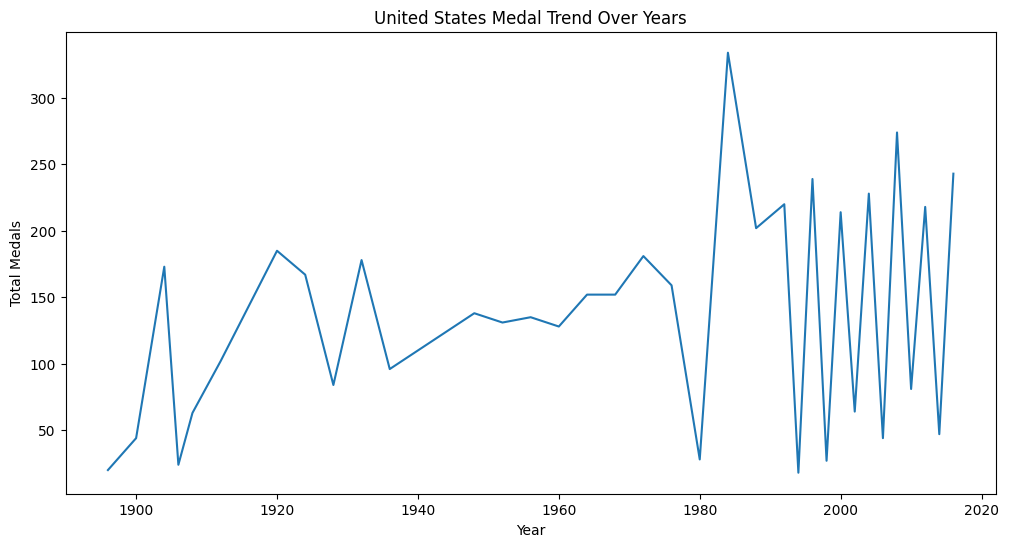

In [72]:

plt.figure(figsize=(12,6))

sns.lineplot(
    x=country_trend.index,
    y=country_trend.values
)

plt.title(f"{country} Medal Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Medals")

plt.show()

In [73]:

sport = 'Athletics'

sport_data = medal_winners[medal_winners['Sport'] == sport]

dominant_country = sport_data.groupby('Team')['Medal'].count().sort_values(ascending=False).head(1)

print("Dominant Country :")
print(dominant_country)

Dominant Country :
Team
United States    999
Name: Medal, dtype: int64


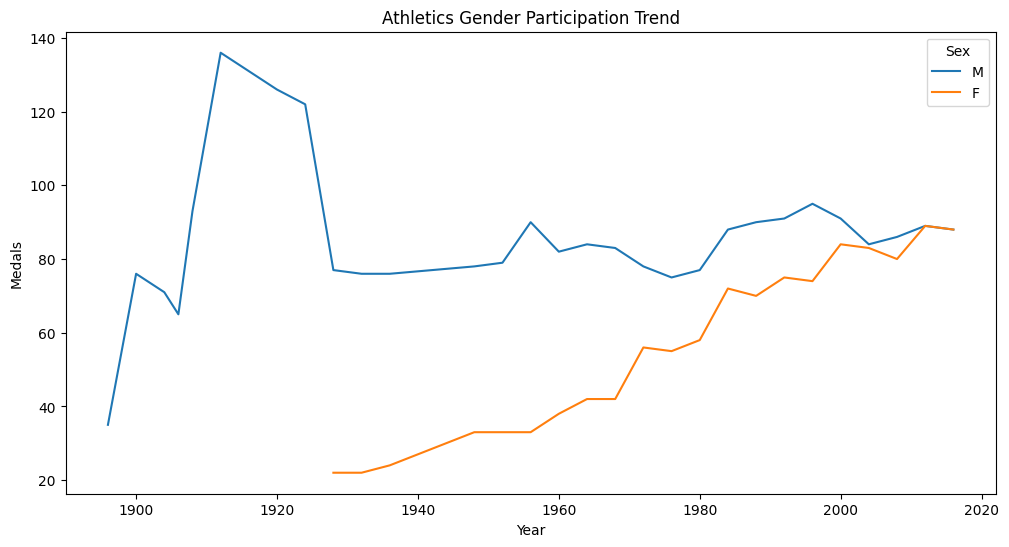

In [74]:

gender_trend_sport = sport_data.groupby(['Year', 'Sex'])['Medal'].count().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=gender_trend_sport,
    x='Year',
    y='Medal',
    hue='Sex'
)

plt.title(f"{sport} Gender Participation Trend")
plt.xlabel("Year")
plt.ylabel("Medals")

plt.show()

In [75]:

avg_age_sport = sport_data['Age'].mean()

print(f"Average Age of Winners in {sport} :", avg_age_sport)

Average Age of Winners in Athletics : 25.02009911894273


# BONUS

Q19. Top 5 Youngest Gold Medalists
Find youngest 5 Gold medal winners.




In [76]:

youngest_gold = gold_medals.sort_values(by='Age').head(5)

print(youngest_gold[['Name', 'Sex', 'Age', 'Team', 'Sport', 'Year']])

                                      Name Sex   Age           Team  \
78544         Marjorie Gestring (-Redlick)   F  13.0  United States   
73581                           Fu Mingxia   F  13.0          China   
52010   Donna Elizabeth de Varona (-Pinto)   F  13.0  United States   
200704       Aileen Muriel Riggin (-Soule)   F  13.0  United States   
119277                          Kim Yun-Mi   F  13.0    South Korea   

                            Sport    Year  
78544                      Diving  1936.0  
73581                      Diving  1992.0  
52010                    Swimming  1960.0  
200704                     Diving  1920.0  
119277  Short Track Speed Skating  1994.0  


Q20. Medal Ratio
For top 5 countries:
Calculate Gold / Total medal ratio.


In [77]:

top5_countries = medal_winners.groupby('Team')['Medal'].count().sort_values(ascending=False).head(5)

gold_counts = gold_medals.groupby('Team')['Medal'].count()

medal_ratio = pd.DataFrame({
    'Total_Medals': top5_countries,
    'Gold_Medals': gold_counts
})

medal_ratio['Gold_Ratio'] = medal_ratio['Gold_Medals'] / medal_ratio['Total_Medals']

print(medal_ratio)

                              Total_Medals  Gold_Medals  Gold_Ratio
Team                                                               
Algeria                                NaN            5         NaN
Amateur Athletic Association           NaN            5         NaN
Ancora                                 NaN            2         NaN
Angelita                               NaN           11         NaN
Argentina                              NaN           85         NaN
...                                    ...          ...         ...
Western Golf Association-1             NaN            9         NaN
White Lady                             NaN            2         NaN
Winnipeg Shamrocks-1                   NaN           12         NaN
Yugoslavia                             NaN          117         NaN
Zimbabwe                               NaN           15         NaN

[238 rows x 3 columns]
